In [1]:
from torch.utils.data import Dataset
import torch
import numpy as np
import sys
import importlib
import fastmri
from numpy import random
import matplotlib.pyplot as plt
from load_mri_data import show_coils, show_multicoil_K_I, convert_K_to_I, convert_I_to_K, rss_combine
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask
import time
import itertools
from torch.utils.data import DataLoader
import glob
import h5py

In [1]:
!pip install pygrappa

  Using cached pygrappa-0.26.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.2 kB)
Using cached pygrappa-0.26.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (537 kB)


In [ ]:
from pygrappa import grappa
import numpy as np

slice_kspace = np.load("/home/biswamitra/health/knee_data/test/deconstructed_test/file1000082_014.npy")
ncoils, sx, sy = slice_kspace.shape[:] # Shape is (Coils, Height, Width)
print(f"Shape: {slice_kspace.shape}")
ctr, pd = int(sx/2), 10
# Calibration region: Center of readout (sx/Height)
calib = slice_kspace[:, ctr-pd:ctr+pd, :].copy() 

# coil_axis=-1 is default, but our data is (Coils, H, W), so we use coil_axis=0
res = grappa(slice_kspace, calib, kernel_size=(5, 5), coil_axis=0)

# image generated by the GRAPPA technique
print(f"Result shape: {res.shape}")
#visualization


Shape: (15, 640, 368)
Result shape: (15, 640, 368)
[[[ 1.64525967e-12+5.85764618e-13j -5.68634441e-13+2.01414428e-12j
   -6.78618999e-13-8.95864979e-13j ...  7.78061426e-15+1.24443067e-12j
    3.11361315e-13+1.67065580e-13j  5.48500590e-14-5.79900819e-13j]
  [ 3.17433471e-13+8.54195837e-13j -1.59550910e-12+2.15168378e-13j
    6.08867449e-13-2.69420066e-13j ... -4.29579820e-13+6.14607594e-13j
   -5.79721275e-13+9.60955707e-13j -5.25066861e-13+1.27473620e-13j]
  [-1.64747827e-13+8.54428507e-13j -1.15828430e-12-1.44809674e-12j
   -3.13347303e-14+6.75708838e-13j ... -2.63797610e-13-6.25842965e-14j
   -7.97713810e-14-6.44881555e-14j  1.63718784e-13+4.11504083e-13j]
  ...
  [-4.92849793e-13-1.31922327e-12j -1.36954890e-12-1.67873614e-12j
    5.67545577e-13-5.64603323e-13j ...  1.95334200e-13+2.18692821e-13j
    1.73828332e-13+4.06599315e-13j  7.10789392e-15+9.24492579e-13j]
  [ 8.60733305e-13+4.73851969e-13j -4.42400511e-13-5.30096529e-13j
   -7.30350784e-13-1.30996505e-13j ...  3.09398394e-

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pygrappa import cgrappa

def rss(data, axis=-1):
    """Compute Root-Sum-of-Squares calculation for viewing."""
    return np.sqrt(np.sum(np.abs(data)**2, axis=axis))

# 1. Load Data
file_path = '/home/biswamitra/health/knee_data/test/deconstructed_test/file1000082_014.npy'
print(f"Loading {file_path}...")
kspace_full = np.load(file_path) # Shape: (coils, x, y)

# 2. Prepare Data for PyGRAPPA
# PyGRAPPA expects (kx, ky, coils). FastMRI is (coils, kx, ky).
# We move the coil axis (0) to the end (-1).
kspace_full = np.moveaxis(kspace_full, 0, -1)
sx, sy, n_coils = kspace_full.shape
print(f"Re-shaped Data: {sx}x{sy} with {n_coils} coils")

# 3. Simulate Undersampling (Acceleration R=4)
# We will skip every 4th line in the Phase Encoding direction (usually dimension 1)
R = 4  # Acceleration Factor
acs_lines = 24  # Number of Auto-Calibration Signal lines (center)

# Create a mask of zeros
mask = np.zeros((sx, sy), dtype=bool)

# Sample every R-th line
mask[:, ::R] = True

# Add the ACS (Calibration) block in the center
# This "fully sampled center" is critical for GRAPPA weights
center_y = sy // 2
pad = acs_lines // 2
mask[:, center_y - pad : center_y + pad] = True

# Apply mask to create the "input" undersampled k-space
kspace_under = kspace_full * mask[..., None] # Broadcast mask to all coils

# Extract the Calibration Data (ACS) explicitly
# PyGRAPPA needs the ACS region as a separate dense block
calib = kspace_full[:, center_y - pad : center_y + pad, :]

print(f"Running GRAPPA (R={R}, ACS={acs_lines})...")
print("This may take 10-60 seconds depending on CPU...")

# 4. Run GRAPPA
# cgrappa is the C++ accelerated version (faster than standard grappa)
# kernel_size=(5, 5): How big the local neighborhood is (standard is 5x5 or 2x3)
recon_kspace = cgrappa(
    kspace_under, 
    calib, 
    kernel_size=(5, 5), 
    coil_axis=-1
)

# 5. Transform to Image Space for Viewing
# We compare:
# A. The fully sampled ground truth (Original)
# B. The Zero-filled image (what it looks like without GRAPPA)
# C. The GRAPPA reconstruction

# A: Ground Truth
img_truth = np.fft.ifft2(kspace_full, axes=(0, 1))
img_truth_rss = rss(img_truth)

# B: Zero-filled (Aliased)
img_zf = np.fft.ifft2(kspace_under, axes=(0, 1))
img_zf_rss = rss(img_zf)

# C: GRAPPA Recon
img_grappa = np.fft.ifft2(recon_kspace, axes=(0, 1))
img_grappa_rss = rss(img_grappa)

print("Reconstruction complete. Plotting...")

# 6. Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

ax[0].imshow(img_truth_rss, cmap='gray', vmin=0, vmax=np.max(img_truth_rss)*0.8)
ax[0].set_title("Ground Truth (Fully Sampled)")
ax[0].axis('off')

ax[1].imshow(img_zf_rss, cmap='gray', vmin=0, vmax=np.max(img_truth_rss)*0.8)
ax[1].set_title(f"Zero-Filled Input (R={R})\n(Aliasing Artifacts)")
ax[1].axis('off')

ax[2].imshow(img_grappa_rss, cmap='gray', vmin=0, vmax=np.max(img_truth_rss)*0.8)
ax[2].set_title("GRAPPA Reconstruction")
ax[2].axis('off')

plt.tight_layout()
plt.show()

Loading /home/biswamitra/health/knee_data/test/deconstructed_test/file1000082_014.npy...
Re-shaped Data: 640x368 with 15 coils
Running GRAPPA (R=4, ACS=24)...
This may take 10-60 seconds depending on CPU...


ValueError: Buffer dtype mismatch, expected 'double complex' but got 'complex float'

In [2]:
class Custom_FMRI_DataLoader_nil(Dataset):
    def __init__(self, data_paths,
                 mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
                 transform=None,
                 input_req=[1, 1, 1, 1, 1],
                 output_req=[1, 1, 1, 1],
                ):
        
        if len(input_req) != 5:
            print("Wrong ip parameters, Assigning Brute force!")
            input_req = [1, 1, 1, 1, 1]
        
        if len(output_req) != 4:
            print("Wrong output parameters, Assigning Brute force!")
            output_req = [1, 1, 1, 1]

        self.paths = data_paths
        self.length = len(self.paths)
        self.mask_func = mask_func
        self.transform = transform

        # 5 input flags
        self.K = input_req[0]
        self.I = input_req[1]
        self.rss_combine = input_req[2]
        self.rss_fft = input_req[3]
        self.mask = input_req[4]

        # 4 output flags
        self.K_full = output_req[0]
        self.I_full = output_req[1]
        self.rss_combine_full = output_req[2]
        self.rss_fft_full = output_req[3]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        dd = {}

        kspace = T.to_tensor(np.load(self.paths[index]))  # (coils, 640, 368, 2)

        # ─── Cached intermediates (None = not yet computed) ───
        _ispace = None
        _rss = None
        _masked_kspace = None
        _mask = None
        _masked_ispace = None
        _masked_rss = None

        # ─── Lazy getters: compute once, cache, reuse ───
        def get_ispace():
            nonlocal _ispace
            if _ispace is None:
                _ispace = fastmri.ifft2c(kspace)
            return _ispace

        def get_rss():
            nonlocal _rss
            if _rss is None:
                _rss = fastmri.rss(fastmri.complex_abs(get_ispace()), dim=0)
            return _rss

        def get_masked():
            nonlocal _masked_kspace, _mask
            if _masked_kspace is None:
                _masked_kspace, _mask, _ = apply_mask(kspace, self.mask_func)
            return _masked_kspace, _mask

        def get_masked_ispace():
            nonlocal _masked_ispace
            if _masked_ispace is None:
                mk, _ = get_masked()
                _masked_ispace = fastmri.ifft2c(mk)
            return _masked_ispace

        def get_masked_rss():
            nonlocal _masked_rss
            if _masked_rss is None:
                _masked_rss = fastmri.rss(fastmri.complex_abs(get_masked_ispace()), dim=0)
            return _masked_rss

        # ═══════════════════════════════════════
        # FULLY SAMPLED OUTPUTS
        # ═══════════════════════════════════════
        if self.K_full:
            dd["full_k_space"] = kspace

        if self.I_full:
            dd["full_i_space"] = get_ispace()

        if self.rss_combine_full:
            dd["full_rss_combined"] = get_rss()

        if self.rss_fft_full:
            dd["full_rss_fft"] = torch.fft.fftshift(
                torch.fft.fft2(get_rss(), norm='ortho')
            )

        # ═══════════════════════════════════════
        # MASKED INPUTS
        # ═══════════════════════════════════════
        if self.K:
            mk, _ = get_masked()
            dd["masked_k_space"] = mk

        if self.I:
            dd["masked_i_space"] = get_masked_ispace()

        if self.rss_combine:
            dd["masked_rss_combined"] = get_masked_rss()

        if self.rss_fft:
            dd["masked_rss_combined_fft"] = torch.fft.fftshift(
                torch.fft.fft2(get_masked_rss(), norm='ortho')
            )

        if self.mask:
            _, m = get_masked()
            dd["mask"] = m

        return dd

In [12]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import os
import glob
from tqdm import tqdm

# ─── Import your dataloader and dependencies ───
# Make sure these are available in your environment
import fastmri
from fastmri.data.transforms import to_tensor
from fastmri.data import transforms as T
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask

DATA_DIR = "/home/biswamitra/health/knee_data/test/deconstructed_test"
data_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))

data_paths=data_paths
batch_size=10
num_workers=8
pin_memory=True
prefetch_factor_list=[2]
num_epochs=1
max_batches=None

dataset = Custom_FMRI_DataLoader_nil(
                    data_paths=data_paths,
                    mask_func=EquiSpacedMaskFunc(
                        center_fractions=[0.08], accelerations=[20]
                    ),
                    transform=None,
                    input_req=[1, 1, 1, 1, 1],
                    output_req=[1, 1, 1, 1],
                )

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
    drop_last=False
)

# Create an iterator object from the dataloader iterable
data_iter = iter(loader)

# Fetch the next batch of data (inputs and labels)
data = next(data_iter)

# benchmark code for dataloader

In [ ]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import os
import glob
from tqdm import tqdm

# ─── Import your dataloader and dependencies ───
# Make sure these are available in your environment
import fastmri
from fastmri.data.transforms import to_tensor
from fastmri.data import transforms as T
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask


def benchmark_dataloader(
    data_paths,
    batch_size=1,
    num_workers_list=[0, 2, 4, 8],
    pin_memory_list=[False, True],
    prefetch_factor_list=[2, 4],
    num_epochs=1,
    max_batches=None,  # Set to limit batches per epoch (useful for quick tests)
):
    """
    Benchmark the Custom_FMRI_DataLoader_nil with various DataLoader settings.
    """

    results = []

    for num_workers in num_workers_list:
        for pin_memory in pin_memory_list:
            for prefetch_factor in prefetch_factor_list:

                # prefetch_factor only valid when num_workers > 0
                if num_workers == 0 and prefetch_factor != 2:
                    continue  # skip redundant combos

                pf_arg = (
                    {"prefetch_factor": prefetch_factor}
                    if num_workers > 0
                    else {}
                )

                dataset = Custom_FMRI_DataLoader_nil(
                    data_paths=data_paths,
                    mask_func=EquiSpacedMaskFunc(
                        center_fractions=[0.08], accelerations=[20]
                    ),
                    transform=None,
                    input_req=[1, 1, 1, 1, 1],
                    output_req=[1, 1, 1, 1],
                )

                loader = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=num_workers,
                    pin_memory=pin_memory,
                    persistent_workers=(num_workers > 0),
                    drop_last=False,
                    **pf_arg,
                )

                config_str = (
                    f"workers={num_workers}, pin_memory={pin_memory}, "
                    f"prefetch={prefetch_factor if num_workers > 0 else 'N/A'}, "
                    f"batch_size={batch_size}"
                )

                print(f"\n{'='*70}")
                print(f"Config: {config_str}")
                print(f"{'='*70}")

                # ─── Warmup (1 batch) ───
                warmup_iter = iter(loader)
                try:
                    _ = next(warmup_iter)
                except StopIteration:
                    print("Dataset is empty!")
                    continue
                del warmup_iter

                # ─── Benchmark ───
                for epoch in range(num_epochs):
                    batch_times = []
                    total_samples = 0
                    epoch_start = time.perf_counter()

                    pbar = tqdm(
                        enumerate(loader),
                        total=len(loader) if max_batches is None else min(max_batches, len(loader)),
                        desc=f"Epoch {epoch+1}/{num_epochs}",
                    )

                    batch_start = time.perf_counter()

                    for batch_idx, batch_data in pbar:
                        batch_end = time.perf_counter()
                        batch_time = batch_end - batch_start

                        # ─── Move to GPU to simulate real training ───
                        if torch.cuda.is_available():
                            for key in batch_data:
                                batch_data[key] = batch_data[key].cuda(non_blocking=True)
                            torch.cuda.synchronize()

                        transfer_end = time.perf_counter()
                        transfer_time = transfer_end - batch_end

                        current_batch_size = next(iter(batch_data.values())).shape[0]
                        total_samples += current_batch_size
                        batch_times.append(batch_time + transfer_time)

                        # Update progress bar
                        avg_time = np.mean(batch_times[-50:])  # rolling avg
                        pbar.set_postfix({
                            "batch_t": f"{batch_time:.4f}s",
                            "transfer_t": f"{transfer_time:.4f}s",
                            "avg_it/s": f"{1.0/avg_time:.2f}",
                            "samples/s": f"{current_batch_size/avg_time:.2f}",
                        })

                        if max_batches and batch_idx + 1 >= max_batches:
                            break

                        batch_start = time.perf_counter()

                    epoch_end = time.perf_counter()
                    epoch_time = epoch_end - epoch_start

                    # ─── Epoch Statistics ───
                    batch_times_arr = np.array(batch_times)
                    stats = {
                        "config": config_str,
                        "epoch": epoch + 1,
                        "total_samples": total_samples,
                        "total_batches": len(batch_times),
                        "epoch_time_s": epoch_time,
                        "throughput_samples_per_s": total_samples / epoch_time,
                        "throughput_batches_per_s": len(batch_times) / epoch_time,
                        "avg_batch_time_s": np.mean(batch_times_arr),
                        "median_batch_time_s": np.median(batch_times_arr),
                        "std_batch_time_s": np.std(batch_times_arr),
                        "min_batch_time_s": np.min(batch_times_arr),
                        "max_batch_time_s": np.max(batch_times_arr),
                        "p95_batch_time_s": np.percentile(batch_times_arr, 95),
                        "p99_batch_time_s": np.percentile(batch_times_arr, 99),
                    }
                    results.append(stats)

                    print(f"\n--- Epoch {epoch+1} Summary ---")
                    print(f"  Total time:           {stats['epoch_time_s']:.2f} s")
                    print(f"  Total samples:        {stats['total_samples']}")
                    print(f"  Total batches:        {stats['total_batches']}")
                    print(f"  Throughput:           {stats['throughput_samples_per_s']:.2f} samples/s")
                    print(f"  Throughput:           {stats['throughput_batches_per_s']:.2f} batches/s")
                    print(f"  Avg batch time:       {stats['avg_batch_time_s']*1000:.2f} ms")
                    print(f"  Median batch time:    {stats['median_batch_time_s']*1000:.2f} ms")
                    print(f"  Std batch time:       {stats['std_batch_time_s']*1000:.2f} ms")
                    print(f"  Min batch time:       {stats['min_batch_time_s']*1000:.2f} ms")
                    print(f"  Max batch time:       {stats['max_batch_time_s']*1000:.2f} ms")
                    print(f"  P95 batch time:       {stats['p95_batch_time_s']*1000:.2f} ms")
                    print(f"  P99 batch time:       {stats['p99_batch_time_s']*1000:.2f} ms")

                # Cleanup
                del loader, dataset

    return results


def print_summary_table(results):
    """Print a nice comparison table."""
    print(f"\n{'='*100}")
    print(f"{'SUMMARY TABLE':^100}")
    print(f"{'='*100}")
    print(
        f"{'Config':<55} | {'Samples/s':>10} | {'Batches/s':>10} | "
        f"{'Avg(ms)':>8} | {'P95(ms)':>8}"
    )
    print(f"{'-'*100}")

    # Sort by throughput (descending)
    sorted_results = sorted(
        results, key=lambda x: x["throughput_samples_per_s"], reverse=True
    )

    best = sorted_results[0]["throughput_samples_per_s"]

    for r in sorted_results:
        speedup = r["throughput_samples_per_s"] / sorted_results[-1]["throughput_samples_per_s"]
        print(
            f"{r['config']:<55} | "
            f"{r['throughput_samples_per_s']:>10.2f} | "
            f"{r['throughput_batches_per_s']:>10.2f} | "
            f"{r['avg_batch_time_s']*1000:>8.2f} | "
            f"{r['p95_batch_time_s']*1000:>8.2f} | "
            f"{'★ BEST' if r['throughput_samples_per_s'] == best else f'{speedup:.2f}x'}"
        )


def profile_single_sample(data_paths, n_samples=5):
    """Profile time spent in each part of __getitem__."""
    print(f"\n{'='*70}")
    print("SINGLE SAMPLE PROFILING (no DataLoader overhead)")
    print(f"{'='*70}")

    dataset = Custom_FMRI_DataLoader_nil(
        data_paths=data_paths,
        mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
        input_req=[1, 1, 1, 1, 1],
        output_req=[1, 1, 1, 1],
    )

    times = []
    for i in range(n_samples):
        start = time.perf_counter()
        sample = dataset[i % len(dataset)]
        end = time.perf_counter()
        times.append(end - start)
        print(f"  Sample {i}: {(end-start)*1000:.2f} ms")

        if i == 0:
            print(f"  Keys returned: {list(sample.keys())}")
            for k, v in sample.items():
                if isinstance(v, torch.Tensor):
                    print(f"    {k}: shape={v.shape}, dtype={v.dtype}")

    print(f"\n  Average __getitem__ time: {np.mean(times)*1000:.2f} ms")
    print(f"  This sets the UPPER BOUND: {1.0/np.mean(times):.2f} samples/s (single-threaded)")


# ═══════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ─── Set your data paths here ───
    DATA_DIR = "/home/biswamitra/health/knee_data/test/deconstructed_test"
    data_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))

    # Or if you have a list already:
    # data_paths = [...]

    print(f"Found {len(data_paths)} files")
    assert len(data_paths) > 0, "No .npy files found!"

    # ─── Step 1: Profile single sample (bottleneck analysis) ───
    profile_single_sample(data_paths, n_samples=5)

    # ─── Step 2: Benchmark with various DataLoader configs ───
    results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=10,
        num_workers_list=[8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=None,  # Use None to run full epoch; set small number for quick test
    )

    # ─── Step 3: Print comparison table ───
    print_summary_table(results)

    # ─── Step 4: Also test different batch sizes with best worker config ───
    print(f"\n\n{'='*70}")
    print("BATCH SIZE SWEEP (with best num_workers from above)")
    print(f"{'='*70}")

    # Find best num_workers
    best_config = max(results, key=lambda x: x["throughput_samples_per_s"])
    print(f"Best config so far: {best_config['config']}")

    batch_results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=4,  # test larger batch
        num_workers_list=[4, 8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=50,
    )

    print_summary_table(results + batch_results)

In [ ]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import os
import glob
from tqdm import tqdm

# ─── Import your dataloader and dependencies ───
# Make sure these are available in your environment
import fastmri
from fastmri.data.transforms import to_tensor
from fastmri.data import transforms as T
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask


def benchmark_dataloader(
    data_paths,
    batch_size=1,
    num_workers_list=[0, 2, 4, 8],
    pin_memory_list=[False, True],
    prefetch_factor_list=[2, 4],
    num_epochs=1,
    max_batches=None,  # Set to limit batches per epoch (useful for quick tests)
):
    """
    Benchmark the Custom_FMRI_DataLoader_nil with various DataLoader settings.
    """

    results = []

    for num_workers in num_workers_list:
        for pin_memory in pin_memory_list:
            for prefetch_factor in prefetch_factor_list:

                # prefetch_factor only valid when num_workers > 0
                if num_workers == 0 and prefetch_factor != 2:
                    continue  # skip redundant combos

                pf_arg = (
                    {"prefetch_factor": prefetch_factor}
                    if num_workers > 0
                    else {}
                )

                dataset = Custom_FMRI_DataLoader_nil(
                    data_paths=data_paths,
                    mask_func=EquiSpacedMaskFunc(
                        center_fractions=[0.08], accelerations=[20]
                    ),
                    transform=None,
                    input_req=[1, 1, 1, 1, 1],
                    output_req=[1, 1, 1, 1],
                )

                loader = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=num_workers,
                    pin_memory=pin_memory,
                    persistent_workers=(num_workers > 0),
                    drop_last=False,
                    **pf_arg,
                )

                config_str = (
                    f"workers={num_workers}, pin_memory={pin_memory}, "
                    f"prefetch={prefetch_factor if num_workers > 0 else 'N/A'}, "
                    f"batch_size={batch_size}"
                )

                print(f"\n{'='*70}")
                print(f"Config: {config_str}")
                print(f"{'='*70}")

                # ─── Warmup (1 batch) ───
                warmup_iter = iter(loader)
                try:
                    _ = next(warmup_iter)
                except StopIteration:
                    print("Dataset is empty!")
                    continue
                del warmup_iter

                # ─── Benchmark ───
                for epoch in range(num_epochs):
                    batch_times = []
                    total_samples = 0
                    epoch_start = time.perf_counter()

                    pbar = tqdm(
                        enumerate(loader),
                        total=len(loader) if max_batches is None else min(max_batches, len(loader)),
                        desc=f"Epoch {epoch+1}/{num_epochs}",
                    )

                    batch_start = time.perf_counter()

                    for batch_idx, batch_data in pbar:
                        batch_end = time.perf_counter()
                        batch_time = batch_end - batch_start

                        # ─── Move to GPU to simulate real training ───
                        if torch.cuda.is_available():
                            for key in batch_data:
                                batch_data[key] = batch_data[key].cuda(non_blocking=True)
                            torch.cuda.synchronize()

                        transfer_end = time.perf_counter()
                        transfer_time = transfer_end - batch_end

                        current_batch_size = next(iter(batch_data.values())).shape[0]
                        total_samples += current_batch_size
                        batch_times.append(batch_time + transfer_time)

                        # Update progress bar
                        avg_time = np.mean(batch_times[-50:])  # rolling avg
                        pbar.set_postfix({
                            "batch_t": f"{batch_time:.4f}s",
                            "transfer_t": f"{transfer_time:.4f}s",
                            "avg_it/s": f"{1.0/avg_time:.2f}",
                            "samples/s": f"{current_batch_size/avg_time:.2f}",
                        })

                        if max_batches and batch_idx + 1 >= max_batches:
                            break

                        batch_start = time.perf_counter()

                    epoch_end = time.perf_counter()
                    epoch_time = epoch_end - epoch_start

                    # ─── Epoch Statistics ───
                    batch_times_arr = np.array(batch_times)
                    stats = {
                        "config": config_str,
                        "epoch": epoch + 1,
                        "total_samples": total_samples,
                        "total_batches": len(batch_times),
                        "epoch_time_s": epoch_time,
                        "throughput_samples_per_s": total_samples / epoch_time,
                        "throughput_batches_per_s": len(batch_times) / epoch_time,
                        "avg_batch_time_s": np.mean(batch_times_arr),
                        "median_batch_time_s": np.median(batch_times_arr),
                        "std_batch_time_s": np.std(batch_times_arr),
                        "min_batch_time_s": np.min(batch_times_arr),
                        "max_batch_time_s": np.max(batch_times_arr),
                        "p95_batch_time_s": np.percentile(batch_times_arr, 95),
                        "p99_batch_time_s": np.percentile(batch_times_arr, 99),
                    }
                    results.append(stats)

                    print(f"\n--- Epoch {epoch+1} Summary ---")
                    print(f"  Total time:           {stats['epoch_time_s']:.2f} s")
                    print(f"  Total samples:        {stats['total_samples']}")
                    print(f"  Total batches:        {stats['total_batches']}")
                    print(f"  Throughput:           {stats['throughput_samples_per_s']:.2f} samples/s")
                    print(f"  Throughput:           {stats['throughput_batches_per_s']:.2f} batches/s")
                    print(f"  Avg batch time:       {stats['avg_batch_time_s']*1000:.2f} ms")
                    print(f"  Median batch time:    {stats['median_batch_time_s']*1000:.2f} ms")
                    print(f"  Std batch time:       {stats['std_batch_time_s']*1000:.2f} ms")
                    print(f"  Min batch time:       {stats['min_batch_time_s']*1000:.2f} ms")
                    print(f"  Max batch time:       {stats['max_batch_time_s']*1000:.2f} ms")
                    print(f"  P95 batch time:       {stats['p95_batch_time_s']*1000:.2f} ms")
                    print(f"  P99 batch time:       {stats['p99_batch_time_s']*1000:.2f} ms")

                # Cleanup
                del loader, dataset

    return results


def print_summary_table(results):
    """Print a nice comparison table."""
    print(f"\n{'='*100}")
    print(f"{'SUMMARY TABLE':^100}")
    print(f"{'='*100}")
    print(
        f"{'Config':<55} | {'Samples/s':>10} | {'Batches/s':>10} | "
        f"{'Avg(ms)':>8} | {'P95(ms)':>8}"
    )
    print(f"{'-'*100}")

    # Sort by throughput (descending)
    sorted_results = sorted(
        results, key=lambda x: x["throughput_samples_per_s"], reverse=True
    )

    best = sorted_results[0]["throughput_samples_per_s"]

    for r in sorted_results:
        speedup = r["throughput_samples_per_s"] / sorted_results[-1]["throughput_samples_per_s"]
        print(
            f"{r['config']:<55} | "
            f"{r['throughput_samples_per_s']:>10.2f} | "
            f"{r['throughput_batches_per_s']:>10.2f} | "
            f"{r['avg_batch_time_s']*1000:>8.2f} | "
            f"{r['p95_batch_time_s']*1000:>8.2f} | "
            f"{'★ BEST' if r['throughput_samples_per_s'] == best else f'{speedup:.2f}x'}"
        )


def profile_single_sample(data_paths, n_samples=5):
    """Profile time spent in each part of __getitem__."""
    print(f"\n{'='*70}")
    print("SINGLE SAMPLE PROFILING (no DataLoader overhead)")
    print(f"{'='*70}")

    dataset = Custom_FMRI_DataLoader_nil(
        data_paths=data_paths,
        mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
        input_req=[1, 1, 1, 1, 1],
        output_req=[1, 1, 1, 1],
    )

    times = []
    for i in range(n_samples):
        start = time.perf_counter()
        sample = dataset[i % len(dataset)]
        end = time.perf_counter()
        times.append(end - start)
        print(f"  Sample {i}: {(end-start)*1000:.2f} ms")

        if i == 0:
            print(f"  Keys returned: {list(sample.keys())}")
            for k, v in sample.items():
                if isinstance(v, torch.Tensor):
                    print(f"    {k}: shape={v.shape}, dtype={v.dtype}")

    print(f"\n  Average __getitem__ time: {np.mean(times)*1000:.2f} ms")
    print(f"  This sets the UPPER BOUND: {1.0/np.mean(times):.2f} samples/s (single-threaded)")


# ═══════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ─── Set your data paths here ───
    DATA_DIR = "/home/biswamitra/health/knee_data/test/deconstructed_test"
    data_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))

    # Or if you have a list already:
    # data_paths = [...]

    print(f"Found {len(data_paths)} files")
    assert len(data_paths) > 0, "No .npy files found!"

    # ─── Step 1: Profile single sample (bottleneck analysis) ───
    profile_single_sample(data_paths, n_samples=5)

    # ─── Step 2: Benchmark with various DataLoader configs ───
    results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=10,
        num_workers_list=[8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=None,  # Use None to run full epoch; set small number for quick test
    )

    # ─── Step 3: Print comparison table ───
    print_summary_table(results)

    # ─── Step 4: Also test different batch sizes with best worker config ───
    print(f"\n\n{'='*70}")
    print("BATCH SIZE SWEEP (with best num_workers from above)")
    print(f"{'='*70}")

    # Find best num_workers
    best_config = max(results, key=lambda x: x["throughput_samples_per_s"])
    print(f"Best config so far: {best_config['config']}")

    batch_results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=4,  # test larger batch
        num_workers_list=[4, 8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=50,
    )

    print_summary_table(results + batch_results)

Found 4092 files

SINGLE SAMPLE PROFILING (no DataLoader overhead)
  Sample 0: 1016.53 ms
  Keys returned: ['full_k_space', 'full_i_space', 'full_rss_combined', 'full_rss_fft', 'masked_k_space', 'masked_i_space', 'masked_rss_combined', 'masked_rss_combined_fft', 'mask']
    full_k_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    full_i_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    full_rss_combined: shape=torch.Size([640, 368]), dtype=torch.float32
    full_rss_fft: shape=torch.Size([640, 368]), dtype=torch.complex64
    masked_k_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    masked_i_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    masked_rss_combined: shape=torch.Size([640, 368]), dtype=torch.float32
    masked_rss_combined_fft: shape=torch.Size([640, 368]), dtype=torch.complex64
    mask: shape=torch.Size([1, 1, 368, 1]), dtype=torch.float32
  Sample 1: 50.27 ms
  Sample 2: 41.77 ms
  Sample 3: 43.11 ms

Epoch 1/1: 100%|██████████| 1023/1023 [03:35<00:00,  4.75it/s, batch_t=0.1442s, transfer_t=0.0089s, avg_it/s=4.97, samples/s=19.89]


--- Epoch 1 Summary ---
  Total time:           218.24 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           18.75 samples/s
  Throughput:           4.69 batches/s
  Avg batch time:       209.54 ms
  Median batch time:    189.78 ms
  Std batch time:       222.71 ms
  Min batch time:       8.74 ms
  Max batch time:       2630.61 ms
  P95 batch time:       547.07 ms
  P99 batch time:       1113.90 ms

Config: workers=8, pin_memory=True, prefetch=4, batch_size=4



Epoch 1/1: 100%|██████████| 1023/1023 [03:54<00:00,  4.36it/s, batch_t=0.1586s, transfer_t=0.0088s, avg_it/s=3.82, samples/s=15.30]



--- Epoch 1 Summary ---
  Total time:           240.55 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           17.01 samples/s
  Throughput:           4.25 batches/s
  Avg batch time:       228.43 ms
  Median batch time:    198.22 ms
  Std batch time:       251.52 ms
  Min batch time:       9.40 ms
  Max batch time:       3205.92 ms
  P95 batch time:       631.42 ms
  P99 batch time:       949.95 ms

Config: workers=16, pin_memory=True, prefetch=2, batch_size=4


...


--- Epoch 1 Summary ---
  Total time:           251.39 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           16.28 samples/s
  Throughput:           4.07 batches/s
  Avg batch time:       231.58 ms
  Median batch time:    190.70 ms
  Std batch time:       384.77 ms
  Min batch time:       8.87 ms
  Max batch time:       7550.68 ms
  P95 batch time:       600.40 ms
  P99 batch time:       1419.33 ms

                                           SUMMARY TABLE                                            
Config                                                  |  Samples/s |  Batches/s |  Avg(ms) |  P95(ms)
----------------------------------------------------------------------------------------------------
workers=8, pin_memory=True, prefetch=2, batch_size=4    |      18.75 |       4.69 |   209.54 |   547.07 | ★ BEST
workers=8, pin_memory=True, prefetch=4, batch_size=4    |      17.01 |       4.25 |   228.43 |   631.42 | 1.07x
workers=16, pin_memory=True, prefet

Epoch 1/1:  98%|█████████▊| 49/50 [00:16<00:00,  2.95it/s, batch_t=0.0006s, transfer_t=0.0099s, avg_it/s=3.02, samples/s=12.07]


--- Epoch 1 Summary ---
  Total time:           19.40 s
  Total samples:        200
  Total batches:        50
  Throughput:           10.31 samples/s
  Throughput:           2.58 batches/s
  Avg batch time:       331.46 ms
  Median batch time:    11.05 ms
  Std batch time:       542.72 ms
  Min batch time:       9.69 ms
  Max batch time:       1966.16 ms
  P95 batch time:       1231.66 ms
  P99 batch time:       1702.88 ms

Config: workers=8, pin_memory=True, prefetch=2, batch_size=4



Epoch 1/1:  98%|█████████▊| 49/50 [00:15<00:00,  3.08it/s, batch_t=0.0004s, transfer_t=0.0121s, avg_it/s=3.18, samples/s=12.73]



--- Epoch 1 Summary ---
  Total time:           17.81 s
  Total samples:        200
  Total batches:        50
  Throughput:           11.23 samples/s
  Throughput:           2.81 batches/s
  Avg batch time:       314.16 ms
  Median batch time:    104.82 ms
  Std batch time:       532.50 ms
  Min batch time:       10.29 ms
  Max batch time:       2983.86 ms
  P95 batch time:       1120.20 ms
  P99 batch time:       2366.37 ms

                                           SUMMARY TABLE                                            
Config                                                  |  Samples/s |  Batches/s |  Avg(ms) |  P95(ms)
----------------------------------------------------------------------------------------------------
workers=8, pin_memory=True, prefetch=2, batch_size=4    |      18.75 |       4.69 |   209.54 |   547.07 | ★ BEST
workers=8, pin_memory=True, prefetch=4, batch_size=4    |      17.01 |       4.25 |   228.43 |   631.42 | 1.65x
workers=16, pin_memory=True, prefetch

Found 7135 files.
data shape:  torch.Size([15, 640, 368, 2])
Elapsed time: 0.5531 seconds


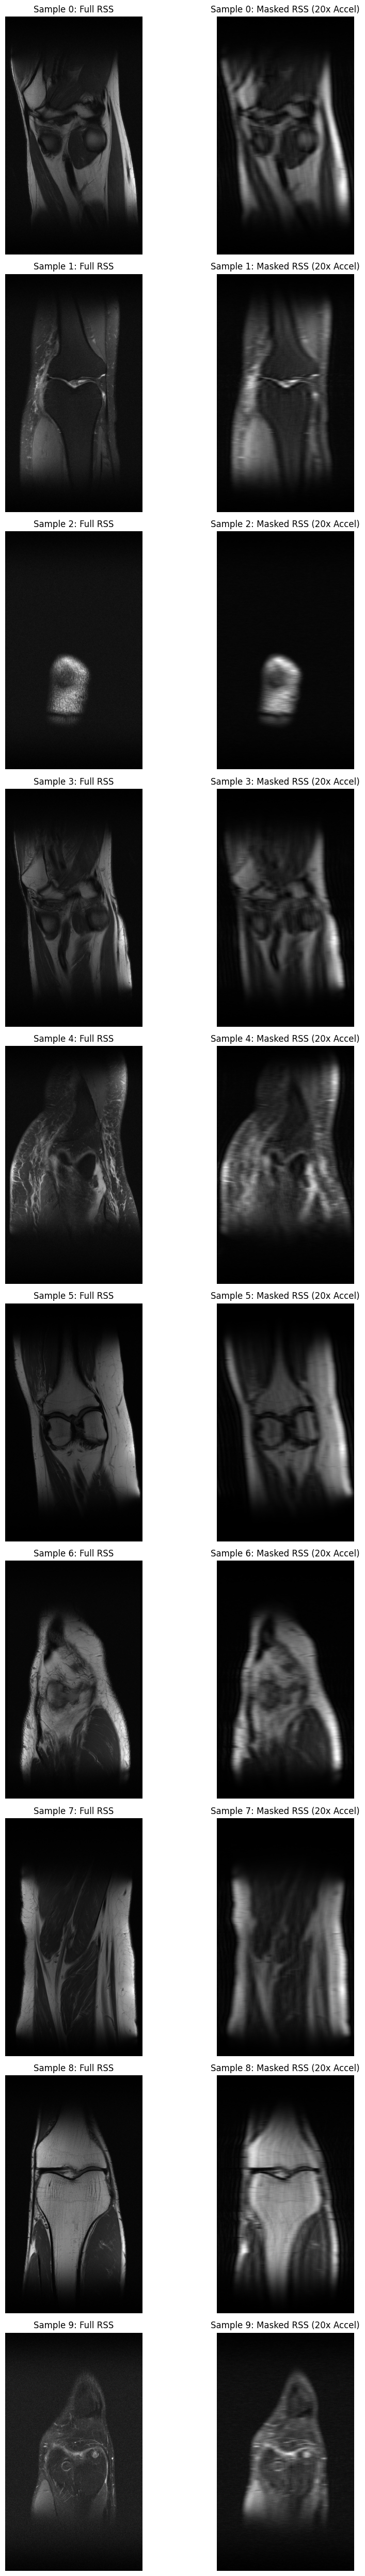

In [5]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from fastmri.data import transforms as T
import os
import glob

# Replace with the actual folder where your .npy files are stored
# Add the missing forward slash at the end of the path
data_folder = "/home/biswamitra/health/knee_data/val/deconstructed_val/" 
your_list_of_paths = sorted(glob.glob(data_folder + "*.npy"))

print(f"Found {len(your_list_of_paths)} files.") # This should no longer be 0
# 1. Initialize your dataset and dataloader
# Ensure input_req[2] and output_req[2] are 1 to enable RSS
dataset = Custom_FMRI_DataLoader_nil(
    data_paths=your_list_of_paths, 
    input_req=[1, 1, 1, 1, 1],   # We only want masked RSS
    output_req=[1, 1, 1, 1]      # and full RSS
)

import time

start_time = time.perf_counter()

loader = DataLoader(dataset, batch_size=10, shuffle=True)

# 2. Grab exactly one batch
batch = next(iter(loader))
# Sending to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
full_rss = batch['full_rss_combined']     # Ground Truth
masked_rss = batch['masked_rss_combined'] # Zero-filled/Aliased
kspace_data = batch['masked_k_space'][0]
print("data shape: ",kspace_data.shape)
full_rss = full_rss.to(device)
masked_rss = masked_rss.to(device)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time:.4f} seconds")
# 3. Extract the RSS images
# Note: fastmri.rss typically returns (Batch, H, W)
full_rss = batch['full_rss_combined']     # Ground Truth
masked_rss = batch['masked_rss_combined'] # Zero-filled/Aliased

# 4. Plotting
num_images = full_rss.shape[0]
fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

for i in range(num_images):
    # Full RSS (Ground Truth)
    axes[i, 0].imshow(full_rss[i].cpu().numpy(), cmap='gray')
    axes[i, 0].set_title(f"Sample {i}: Full RSS")
    axes[i, 0].axis('off')
    
    # Masked RSS (Aliased/Input)
    axes[i, 1].imshow(masked_rss[i].cpu().numpy(), cmap='gray')
    axes[i, 1].set_title(f"Sample {i}: Masked RSS (20x Accel)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()